# Benchmark Explorer

Choose a MissLearn model family and run the six-arm benchmark on
controlled synthetic data. Every arm uses the **same model class** and
differs only in how the missing values are handled:

| Arm | Treatment |
|-----|-----------|
| Drop rows | listwise deletion |
| Drop cols | discard every column containing a missing value |
| Mean | per-column mean imputation |
| kNN | `KNNImputer(n_neighbors=5)` |
| MICE | `IterativeImputer`, the strongest conventional competitor |
| FIML | the MissLearn estimator on the incomplete matrix |

Because the model class is fixed and the conventional arms receive the
same internal standardisation the MissLearn estimator applies, a
difference between arms is attributable to the missing-data treatment
and not to model capacity or preprocessing. For the penalized families
the regularisation strength is tuned by inner cross-validation on both
arms.

Tick **save this run to disk** beside the family selector to keep every
figure and table this run produces, under `explorer_output/`. Left
unticked nothing is written, which is the default.

---
## 0. Setup

In [3]:
import sys, os, pathlib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

_BENCH = pathlib.Path.cwd()
sys.path.insert(0, str(_BENCH.parent))   # the MissLearn package
sys.path.insert(0, str(_BENCH))          # benchmark_core, family_registry

import benchmark_core as bc
import family_registry as fr

# ---- Readability ------------------------------------------------------
# Large enough to read on a projector or in a GitHub preview, with padding
# so titles never sit on top of the axes.
plt.rcParams.update({
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13.5,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 16,
    "axes.titlepad": 12,
    "axes.labelpad": 8,
    "figure.constrained_layout.use": True,
    "figure.dpi": 110,
    "savefig.bbox": "tight",
})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 4)

# Saving is controlled by the checkbox beside the family dropdown below,
# not by a constant here. explorer_io routes every figure the notebook draws
# through one place that knows whether to write it.
import explorer_io as eio
eio.install()

print("Ready. Available model families:\n")
fr.describe()

Ready. Available model families:

KEY             MODEL CLASS                            SWEEP?
----------------------------------------------------------------------
MissLinear      Linear / logistic regression           yes
MissRidge       Ridge (L2 penalized)                   yes
MissLASSO       LASSO (L1 penalized)                   yes
MissBayes       Generative Gaussian                    yes
MissNeighbors   k-nearest neighbours (expected distance) yes
MissSupport     Support vector (expected kernel)       yes
MissGaussian    Gaussian process (marginalised kernel) yes


---
## 1. Choose a family

In [5]:
# ======================================================================
#  CHOOSE WHAT TO RUN
#  Pick from the dropdown. The dropdown IS the selection: the cells below
#  read it when they run, so change it and simply run on. There is no need
#  to re-run this cell, and re-running it keeps your choice rather than
#  resetting it.
# ======================================================================
FAMILY_FALLBACK = "MissLinear"   # used only when ipywidgets is unavailable
N_FOLDS  = 10
RNG_SEED = 42
MISS_RATE = 0.25

try:
    import ipywidgets as W
    _HAVE_WIDGETS = True
except ImportError:
    _HAVE_WIDGETS = False

if _HAVE_WIDGETS:
    _opts = [(f"{k}  --  {v['label']}", k)
             for k, v in fr.FAMILIES.items()]
    _keys = [k for _, k in _opts]
    # Reuse an existing dropdown so re-running this cell does not discard a
    # selection already made.
    _prev = globals().get("_dd", None)
    if _prev is not None and getattr(_prev, "value", None) in _keys:
        _start = _prev.value
    else:
        _start = FAMILY_FALLBACK if FAMILY_FALLBACK in _keys else _keys[0]
    _dd = W.Dropdown(options=_opts, value=_start, description="Family:",
                     layout=W.Layout(width="640px"),
                     style={"description_width": "90px"})
    display(_dd)
else:
    _dd = None
    print("ipywidgets not installed; edit FAMILY_FALLBACK above instead.")


if _HAVE_WIDGETS:
    # Reused on re-run for the same reason as the dropdown: rebuilding it
    # would silently untick a box the user had ticked.
    _prev_save = globals().get("_save", None)
    _save = W.Checkbox(
        value=bool(getattr(_prev_save, "value", False)),
        description="save this run to disk", indent=False)
    display(_save)
else:
    _save = None
    SAVE = False        # set True to write output when widgets are absent


def saving_enabled():
    """Whether this run should be written to disk.

    The checkbox is the switch when widgets are available; SAVE is the
    fallback for when they are not. Read at the moment the run starts, so
    ticking the box does not require re-running this cell.
    """
    if _HAVE_WIDGETS and _save is not None:
        return bool(_save.value)
    return bool(globals().get("SAVE", False))


def current_family():
    """The family to run.

    Read from the widget every time rather than cached in a global, so a
    change in the dropdown takes effect on the next cell without this one
    needing to run again.
    """
    if _HAVE_WIDGETS and _dd is not None:
        return _dd.value
    return FAMILY_FALLBACK


print("Current selection:", current_family(),
      "->", fr.FAMILIES[current_family()]["label"])


Dropdown(description='Family:', layout=Layout(width='640px'), options=(('MissLinear  --  Linear / logistic reg…

Current selection: MissLinear -> Linear / logistic regression


---
## 2. Build the datasets

In [7]:
# Read the dropdown now, not whatever a global was last set to.
FAMILY = current_family()
spec = fr.FAMILIES[FAMILY]

# Opens the output directory when the save box is ticked, and
# resets the figure counter so this run does not append to the last.
OUT_DIR = eio.begin(FAMILY, save=saving_enabled())
display(Markdown(f"## {spec['label']}\n\n{spec['blurb']}"))

# The Gaussian process is O(n^3), so it uses the small datasets only.
_small_only = spec.get("small_only", False)
_n_ds = 1 if _small_only else 2
print(f"Model class held fixed; only the missing-data strategy varies.")
print(f"Datasets: {'small only (O(n^3) model)' if _small_only else 'small + medium'}")

## Linear / logistic regression

Exact FIML linear and logistic regression. The reference family: on linear ground truth it should sit at the efficiency bound, so parity with good imputation is the expected result.

Model class held fixed; only the missing-data strategy varies.
Datasets: small + medium


In [8]:
reg_datasets = bc.make_regression_datasets(mar_rate=MISS_RATE,
                                           seed=RNG_SEED)[:_n_ds]
clf_datasets = bc.make_classification_datasets(mar_rate=MISS_RATE,
                                               seed=RNG_SEED)[:_n_ds]
display(bc.dataset_summary_table(reg_datasets, clf_datasets))

n   p Missing rate                                        Description
Task           Name                                                                                           
Regression     Regression-Small        300   5        22.5%  n=300, p=5, low noise, 4 informative features,...
               Regression-Medium      1500  10        23.6%  n=1,500, p=10, moderate noise, correlated feat...
Classification Classification-Small    400   5        24.6%  n=400, p=5, balanced classes, clear separation...
               Classification-Medium  1500  10        23.6%  n=1,500, p=10, imbalanced (30% positive), corr...

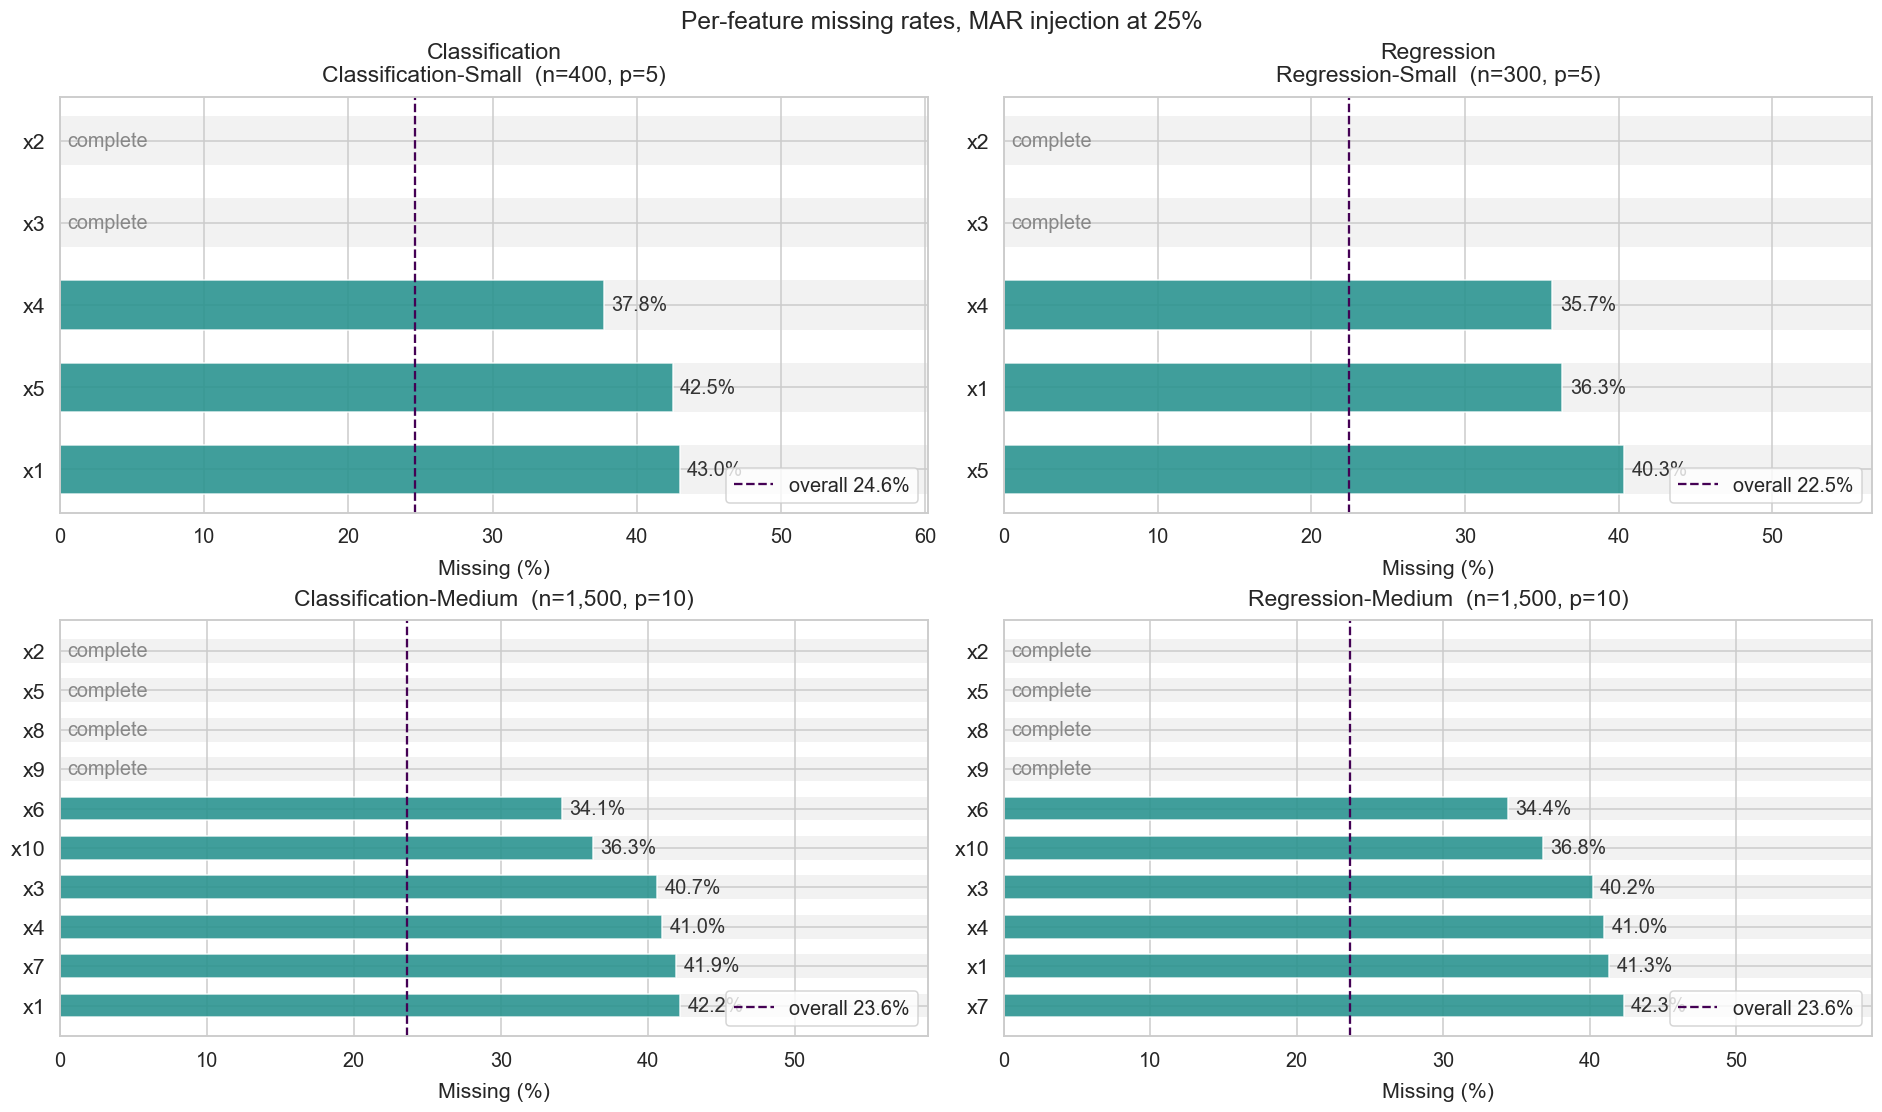

In [9]:
_ = bc.plot_missing_profile(
    clf_datasets + reg_datasets,
    title=f"Per-feature missing rates, MAR injection at {MISS_RATE*100:.0f}%",
    col_labels=["Classification", "Regression"])
plt.show()

---
## 3. Regression

Five-fold cross-validation; every arm sees the identical incomplete
matrices and is scored against the same held-out targets.

In [ ]:
reg_folds, reg_agg = {}, {}
for ds in reg_datasets:
    print(f"  {ds['name']}  (n={ds['n']:,}, p={ds['p']}) ... ",
          end="", flush=True)
    f = bc.run_cv(ds, spec["reg_sklearn"], spec["reg_fiml"],
                  task="regression", n_splits=N_FOLDS,
                  rng_seed=RNG_SEED)
    reg_folds[ds["name"]] = f
    reg_agg[ds["name"]] = bc.aggregate_folds(f)
    print("done")
_tbl_reg = bc.make_results_table(reg_datasets, reg_agg, bc.REG_METRIC_META)
eio.save_table(_tbl_reg, "results_regression")
display(_tbl_reg)

  Regression-Small  (n=300, p=5) ... done
  Regression-Medium  (n=1,500, p=10) ... 

In [ ]:
for fig in bc.plot_bars(reg_datasets, reg_agg, bc.REG_METRIC_META,
                        model_name=spec["reg_name"], task="regression",
                        n_folds=N_FOLDS):
    plt.show()

In [ ]:
for fig in bc.plot_strips(reg_datasets, reg_folds, bc.REG_METRIC_META,
                          model_name=spec["reg_name"],
                          task="regression"):
    plt.show()

In [ ]:
_ = bc.plot_gain_heatmap(reg_datasets, reg_agg, bc.REG_METRIC_META,
                         model_name=spec["reg_name"],
                         task="regression")
plt.show()

print("Paired t-tests, two-sided, alpha=0.05:\n")
display(bc.compute_ttests(reg_datasets, reg_folds,
                          bc.REG_METRIC_META, N_FOLDS))

---
## 4. Classification

In [ ]:
clf_folds, clf_agg = {}, {}
for ds in clf_datasets:
    print(f"  {ds['name']}  (n={ds['n']:,}, p={ds['p']}, "
          f"pos={ds['pos_rate']*100:.0f}%) ... ", end="", flush=True)
    f = bc.run_cv(ds, spec["clf_sklearn"], spec["clf_fiml"],
                  task="classification", n_splits=N_FOLDS,
                  rng_seed=RNG_SEED)
    clf_folds[ds["name"]] = f
    clf_agg[ds["name"]] = bc.aggregate_folds(f)
    print("done")
_tbl_clf = bc.make_results_table(clf_datasets, clf_agg, bc.CLF_METRIC_META)
eio.save_table(_tbl_clf, "results_classification")
display(_tbl_clf)

In [ ]:
for fig in bc.plot_bars(clf_datasets, clf_agg, bc.CLF_METRIC_META,
                        model_name=spec["clf_name"],
                        task="classification", n_folds=N_FOLDS):
    plt.show()

In [ ]:
for fig in bc.plot_strips(clf_datasets, clf_folds, bc.CLF_METRIC_META,
                          model_name=spec["clf_name"],
                          task="classification"):
    plt.show()

In [ ]:
_ = bc.plot_gain_heatmap(clf_datasets, clf_agg, bc.CLF_METRIC_META,
                         model_name=spec["clf_name"],
                         task="classification")
plt.show()

print("Paired t-tests, two-sided, alpha=0.05:\n")
display(bc.compute_ttests(clf_datasets, clf_folds,
                          bc.CLF_METRIC_META, N_FOLDS))

---
## How to read this

* Compare arms **within a row**. Rows are different datasets and are
  not comparable with one another.
* Column deletion is usually the worst arm by a wide margin, because it
  discards whole variables to avoid a few holes.
* On well-specified linear ground truth, parity between FIML and good
  imputation is the *expected* result, not a disappointment: a correct
  likelihood combined with good imputation both approach the efficiency
  bound. The argument for FIML there is one deterministic fit, honest
  standard errors, and intervals that widen with missingness.
* The clearest gains usually appear in the Brier score rather than in
  point accuracy, because marginalisation propagates feature
  uncertainty into the predicted probabilities.
* Tick the save box beside the selector to keep this run's figures
  and tables under `explorer_output/`.
* To run every family in one go, use the scripts in `scripts/`.

In [ ]:
# Write the run record and report what was kept. Harmless when the
# save box is unticked: it just says nothing was written.
eio.finish()
